In [1]:
using Pkg
Pkg.activate(normpath(@__DIR__, ".."))

  Activating project at `~/DART`


In [2]:
using CSV, DataFrames
include(normpath(joinpath(@__DIR__, "..", "utils", "utils.jl")))  #to calculate R^2

fb = CSV.read("../eve_analysis/w7_K3_t0_fluo_hmm_results_final.csv", DataFrame); # inference results from cpHMM

cpHMM fit: y = -0.11887 * x + 0.81701,  R² = 0.0702
DART  fit: y = -1.29049 * x + 0.93602,  R² = 0.722


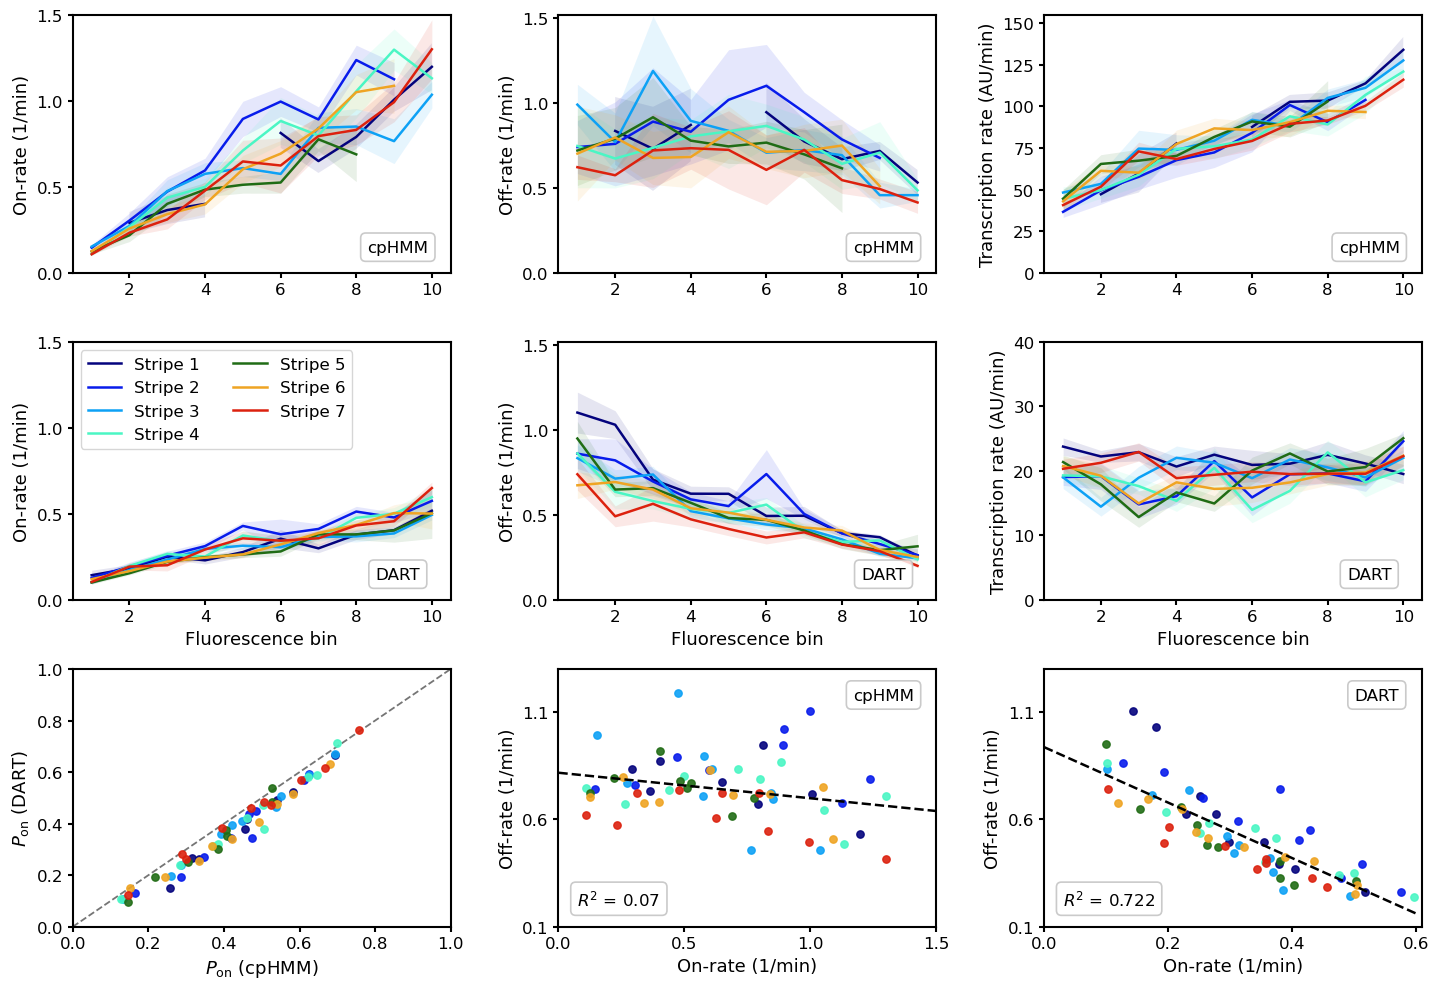

In [4]:
using DataFrames, Statistics, JLD2, StatsBase
using PyPlot

# ---- palette ----
cols = ["#04037d", "#081ceb", "#0da1f5", "#4af6c4","#206c15", "#efa423", "#dc210e"]

# ------------------------------
# Load precomputed bootstrap summaries
# ------------------------------
@load "../eve_analysis/boot_dl_results.jld2" mean_onrate sd_onrate mean_offrate sd_offrate mean_Pon sd_Pon mean_rate sd_rate;

# ------------------------------
# Figure: 3 rows × 3 cols
# ------------------------------
fig, axes = subplots(3, 3, figsize=(14.5, 10))

ax1_on, ax1_off, ax1_rate = axes[1, :]
ax2_on, ax2_off, ax2_rate = axes[2, :]
ax3, ax_cp, ax_da = axes[3, :]

fs1 = 13; fs2 = 12; wd = 1.5
fgroups = 1:10

# ============================================================
# Row 1: cpHMM  (on-rate, off-rate, transcription rate vs bin)
# ============================================================
for s in 1:7
    df = filter(row -> row.stripe_id == s, fb)
    nrow(df) == 0 && continue
    sort!(df, :mean_fluo)
    x = 1:10

    y_on, e_on = df.kon, df.kon_err
    ax1_on.plot(x, y_on, color=cols[s], lw=1.8, label="Stripe $s")
    ax1_on.fill_between(x, y_on .- e_on, y_on .+ e_on; color=cols[s], alpha=0.1, lw=0)

    y_off, e_off = df.koff, df.koff_err
    ax1_off.plot(x, y_off, color=cols[s], lw=1.8)
    ax1_off.fill_between(x, y_off .- e_off, y_off .+ e_off; color=cols[s], alpha=0.1, lw=0)

    y_r, e_r = df.r, df.r_err
    ax1_rate.plot(x, y_r, color=cols[s], lw=1.8)
    ax1_rate.fill_between(x, y_r .- e_r, y_r .+ e_r; color=cols[s], alpha=0.1, lw=0)
end

# ============================================================
# Row 2: DART  (on-rate, off-rate, transcription rate vs bin)
# ============================================================
for s in 1:7
    x = fgroups

    y_on, sd_on = mean_onrate[s, :], sd_onrate[s, :]
    ax2_on.plot(x, y_on, color=cols[s], lw=1.8, label="Stripe $s")
    ax2_on.fill_between(x, y_on .- sd_on, y_on .+ sd_on; color=cols[s], alpha=0.1, lw=0)

    y_off, sd_off = mean_offrate[s, :], sd_offrate[s, :]
    ax2_off.plot(x, y_off, color=cols[s], lw=1.8)
    ax2_off.fill_between(x, y_off .- sd_off, y_off .+ sd_off; color=cols[s], alpha=0.1, lw=0)

    rates, errors = mean_rate[s, :], sd_rate[s, :]
    ax2_rate.plot(x, rates, color=cols[s], lw=1.8)
    ax2_rate.fill_between(x, rates .- errors, rates .+ errors; color=cols[s], alpha=0.1, lw=0)
end

# ============================================================
# Row 3: Pon scatter + koff vs kon scatters
# ============================================================
xs_cp = Float64[]; ys_cp = Float64[]
xs_da = Float64[]; ys_da = Float64[]

# -- Col 1: Pon (cpHMM) vs Pon (DART) scatter --
all_x = Float64[]
all_y = Float64[]

for s in 1:7
    # cpHMM Pon for this stripe, ordered by bin
    df = filter(row -> row.stripe_id == s && row.fluo_bin <= 10, fb)
    nrow(df) == 0 && continue
    sort!(df, [:fluo_bin])
    denom_fb = df.kon .+ df.koff
    Pon_fb   = df.kon ./ denom_fb

    # DART Pon for the same bins
    n_bins = min(length(Pon_fb), size(mean_Pon, 2))
    x = Pon_fb[1:n_bins]
    y = vec(mean_Pon[s, 1:n_bins])

    keep = .!(isnan.(x) .| isnan.(y))
    x = x[keep]; y = y[keep]

    ax3.scatter(x, y; s=28, color=cols[s], label="Stripe $s", alpha=0.9)

    append!(all_x, x); append!(all_y, y)
end

# 1:1 reference line
ax3.plot([0, 1], [0, 1]; lw=1.3, ls="--", color="#666666", alpha=0.9, zorder=0)

# -- Col 2: cpHMM scatter (koff vs kon) --
for s in 1:7
    df = filter(row -> row.stripe_id == s && row.fluo_bin <= 10, fb)
    nrow(df) == 0 && continue
    sort!(df, [:fluo_bin])
    kon_cp  = df.kon
    koff_cp = df.koff
    append!(xs_cp, kon_cp)
    append!(ys_cp, koff_cp)
    ax_cp.scatter(kon_cp, koff_cp; s=28, color=cols[s], label="Stripe $s", alpha=0.9)
end

# -- Col 3: DART scatter (koff vs kon) --
for s in 1:7
    kon_da  = vec(mean_onrate[s, :])
    koff_da = vec(mean_offrate[s, :])
    keep = .!(isnan.(kon_da) .| isnan.(koff_da))
    kon_da  = kon_da[keep]
    koff_da = koff_da[keep]
    append!(xs_da, kon_da)
    append!(ys_da, koff_da)
    ax_da.scatter(kon_da, koff_da; s=28, color=cols[s], label="Stripe $s", alpha=0.9)
end

# ---- Linear fits (row 3, cols 2–3) ----
m_cp, b_cp, r2_cp = fit_line(xs_cp, ys_cp)
xline_cp = range(0, 1.5, length=200)
ax_cp.plot(xline_cp, m_cp .* xline_cp .+ b_cp, "k--", lw=1.8, label="Linear fit")

m_da, b_da, r2_da = fit_line(xs_da, ys_da)
xline_da = range(0, 0.6, length=200)
ax_da.plot(xline_da, m_da .* xline_da .+ b_da, "k--", lw=1.8, label="Linear fit")

# ---- Linear fits (row 1, cpHMM: rate vs bin, pooled across stripes) ----
xs_on_cp  = Float64[]; ys_on_cp  = Float64[]
xs_off_cp = Float64[]; ys_off_cp = Float64[]

for s in 1:7
    df = filter(row -> row.stripe_id == s && row.fluo_bin <= 10, fb)
    nrow(df) == 0 && continue
    append!(xs_on_cp,  df.fluo_bin); append!(ys_on_cp,  df.kon)
    append!(xs_off_cp, df.fluo_bin); append!(ys_off_cp, df.koff)
end

m_on_cp,  b_on_cp,  r2_on_cp  = fit_line(xs_on_cp,  ys_on_cp)
m_off_cp, b_off_cp, r2_off_cp = fit_line(xs_off_cp, ys_off_cp)

# ---- Linear fits (row 2, DART: rate vs bin, pooled across stripes) ----
xs_on_da  = Float64[]; ys_on_da  = Float64[]
xs_off_da = Float64[]; ys_off_da = Float64[]

for s in 1:7
    x      = collect(fgroups)
    kon_s  = vec(mean_onrate[s, :])
    koff_s = vec(mean_offrate[s, :])

    keep_on  = .!isnan.(kon_s)
    keep_off = .!isnan.(koff_s)

    append!(xs_on_da,  x[keep_on]);   append!(ys_on_da,  kon_s[keep_on])
    append!(xs_off_da, x[keep_off]);  append!(ys_off_da, koff_s[keep_off])
end

m_on_da,  b_on_da,  r2_on_da  = fit_line(xs_on_da,  ys_on_da)
m_off_da, b_off_da, r2_off_da = fit_line(xs_off_da, ys_off_da)

# ============================================================
# Axis labels
# ============================================================
# Rows 1–2
ax1_on.set_ylabel("On-rate (1/min)",              fontsize=fs1)
ax1_off.set_ylabel("Off-rate (1/min)",             fontsize=fs1)
ax1_rate.set_ylabel("Transcription rate (AU/min)", fontsize=fs1)
ax2_on.set_ylabel("On-rate (1/min)",               fontsize=fs1)
ax2_off.set_ylabel("Off-rate (1/min)",              fontsize=fs1)
ax2_rate.set_ylabel("Transcription rate (AU/min)",  fontsize=fs1)

# Row 2 x-labels (bottom of the top 2×3 block)
for ax in (ax2_on, ax2_off, ax2_rate)
    ax.set_xlabel("Fluorescence bin", fontsize=fs1)
end

# Row 3
ax3.set_xlabel(L"$P_\mathrm{on}$ (cpHMM)", fontsize=fs1)
ax3.set_ylabel(L"$P_\mathrm{on}$ (DART)",  fontsize=fs1)
ax_cp.set_xlabel("On-rate (1/min)",    fontsize=fs1)
ax_cp.set_ylabel("Off-rate (1/min)",   fontsize=fs1)
ax_da.set_xlabel("On-rate (1/min)",    fontsize=fs1)
ax_da.set_ylabel("Off-rate (1/min)",   fontsize=fs1)

# ============================================================
# Axis limits & ticks
# ============================================================
# Rows 1–2
ax1_on.set_ylim(0, 1.5);       ax2_on.set_ylim(0, 1.5)
ax1_on.set_yticks(0:0.5:1.5);  ax2_on.set_yticks(0:0.5:1.5)
ax1_off.set_ylim(0, 1.52);     ax2_off.set_ylim(0, 1.52)
ax1_off.set_yticks(0:0.5:1.5); ax2_off.set_yticks(0:0.5:1.5)
ax1_rate.set_ylim(0, 155)
ax2_rate.set_ylim(0, 40)

for ax in axes[1:2, :]
    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(2:2:10)
end

# Row 3
ax3.set_xlim(0, 1);    ax3.set_ylim(0, 1)
ax3.set_xticks(0:0.2:1); ax3.set_yticks(0:0.2:1)
ax_cp.set_xlim(0, 1.3);       ax_cp.set_xticks(0.:0.5:1.5)
ax_da.set_xlim(0, 0.61);       ax_da.set_xticks(0:0.2:0.6)
for ax in (ax_cp, ax_da)
    ax.set_ylim(0.1, 1.3)
    ax.set_yticks(0.1:0.5:1.4)
end

# ---- Shared tick / spine styling ----
for ax in axes
    ax.tick_params(axis="both", labelsize=fs2, width=wd)
    for spine in ax.spines.values()
        spine.set_linewidth(wd)
    end
end

# ============================================================
# Method labels
# ============================================================
for ax in (ax1_on, ax1_off, ax1_rate)
    ax.text(0.86, 0.07, "cpHMM", transform=ax.transAxes,
            fontsize=fs2, ha="center", va="bottom",
            bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
                      :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))
end
for ax in (ax2_on, ax2_off, ax2_rate)
    ax.text(0.86, 0.07, "DART", transform=ax.transAxes,
            fontsize=fs2, ha="center", va="bottom",
            bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
                      :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))
end
ax_cp.text(0.86, 0.87, "cpHMM", transform=ax_cp.transAxes, fontsize=fs2, ha="center", va="bottom",
    bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
              :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))
ax_da.text(0.88, 0.87, "DART", transform=ax_da.transAxes, fontsize=fs2, ha="center", va="bottom",
    bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
              :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))

# ---- R² value boxes (row 3, columns 2 and 3) ----
ax_cp.text(0.05, 0.07, L"$R^2$ = "*"$(round(r2_cp, digits=3))",
    transform=ax_cp.transAxes, fontsize=fs2, ha="left", va="bottom",
    bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
              :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))

ax_da.text(0.05, 0.07, L"$R^2$ = "*"$(round(r2_da, digits=3))",
    transform=ax_da.transAxes, fontsize=fs2, ha="left", va="bottom",
    bbox=Dict(:facecolor=>"white", :edgecolor=>"#bdbdbd", :alpha=>0.8,
              :boxstyle=>"round,pad=0.4,rounding_size=0.3", :linewidth=>1.2))

# ---- Legend ----
ax2_on.legend(ncol=2, loc="upper left", fontsize=fs2)

# ---- Layout & save ----
plt.tight_layout(w_pad=2.5)
savefig("figs/eve_compare_combined.pdf", bbox_inches="tight")

println("cpHMM fit: y = $(round(m_cp,digits=5)) * x + $(round(b_cp,digits=5)),  R² = $(round(r2_cp,digits=4))")
println("DART  fit: y = $(round(m_da,digits=5)) * x + $(round(b_da,digits=5)),  R² = $(round(r2_da,digits=4))")

#### example traces

In [19]:
# read traces files (7 stripes 10 fuo groups)
all_traces10 = CSV.read("../eve_analysis/all_concat_traces10.csv", DataFrame);

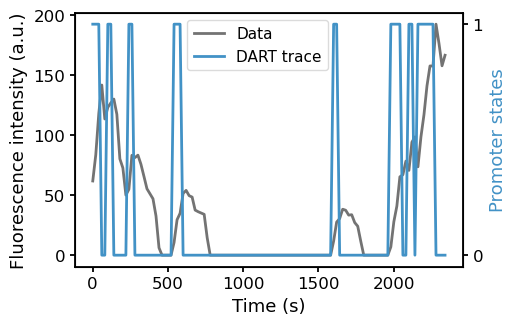

In [20]:
@load "../eve_analysis/trained_trace10/dl_trace62.jld2" dl_trace62;

trace_subset = filter(row -> row.StripeID == 6 && row.fluobin_group == 2, all_traces10)

grouped = groupby(trace_subset, :particle_id)
traces_test = [collect(g.fluo) for g in grouped];

fig, (ax1) = plt.subplots(1,1,figsize=(5.0,3.3))

fs1 = 13
fs2 = 12
lw_val = 2
#t_int =1001:1500; 
id = 29 #29#24 #6 #1
y1 = traces_test[id]  #raw trace
x = 1:20:length(traces_test[id])*20

# binarized trace
start_idx = sum(length.(traces_test[1:id-1])) + 1
end_idx = start_idx + length(traces_test[id]) - 1
y2 = dl_trace62[id]#data_binar[start_idx:end_idx]

ax1.plot(x, y1,color="#737373",lw=lw_val,label="Data",zorder=1)#"#4575b4"
ax1.set_ylabel("Fluorescence intensity (a.u.)",fontsize=fs1); 
ax1.tick_params(axis="y");
ax1.set_xlabel("Time (s)",fontsize=fs1)
#ax1.set_title("An example trace")
    
ax11 = ax1.twinx()
ax11.plot(x, y2, color="#4292c6", label="DART trace",lw=lw_val,zorder=2) #"#fdae61"
ax11.set_ylabel("Promoter states",fontsize=fs1,color="#4292c6"); ax11.tick_params(axis="y") ##fdae61

ax11.set_ylim(-0.05, 1.05)
ax11.set_yticks([0.0, 1.0])
ax1.tick_params(axis="both", labelsize=fs2)
ax11.tick_params(axis="both", labelsize=fs2)

wd = 1.3
ax1.tick_params(axis="both", labelsize=fs2, width=wd)
ax11.tick_params(axis="both", labelsize=fs2, width=wd)
    
for spine in ax1.spines.values()
    spine.set_linewidth(wd)
end


# Get handles and labels from both ax1 and ax11
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax11.get_legend_handles_labels()
handles = vcat(h1, h2)
labels = vcat(l1, l2)
leg = fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.49, 0.88), fontsize=11,framealpha=0.7); # Put a combined legend on ax1 (or anywhere you prefer)
#bbox_to_anchor=(0.13, 0.69),
leg.set_zorder(3)
#fig.savefig("figs/eve_binar62.pdf",bbox_inches="tight");

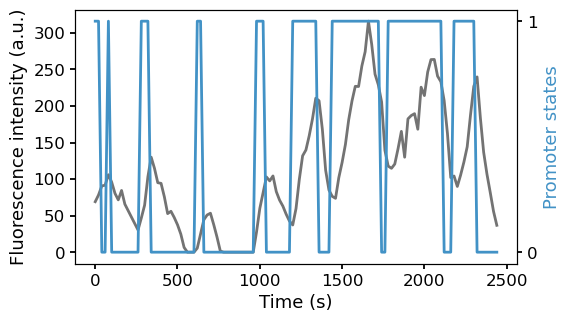

2-element Vector{String}:
 "Data"
 "DART trace"

In [22]:
@load "../eve_analysis/trained_trace10/dl_trace28.jld2" dl_trace28;

trace_subset = filter(row -> row.StripeID == 2 && row.fluobin_group == 8, all_traces10)

grouped = groupby(trace_subset, :particle_id)
traces_test = [collect(g.fluo) for g in grouped];

fig, (ax1) = plt.subplots(1,1,figsize=(5.7,3.3))

fs1 = 13
fs2 = 12
lw_val = 2
#t_int =1001:1500; 
id = 5#12 #5 
y1 = traces_test[id]  #raw trace
x = 1:20:length(traces_test[id])*20

# binarized trace
start_idx = sum(length.(traces_test[1:id-1])) + 1
end_idx = start_idx + length(traces_test[id]) - 1
y2 = dl_trace28[id]#data_binar[start_idx:end_idx]

ax1.plot(x, y1,color="#737373",lw=lw_val,label="Data",zorder=1)#"#4575b4"
ax1.set_ylabel("Fluorescence intensity (a.u.)",fontsize=fs1); 
ax1.tick_params(axis="y");
ax1.set_xlabel("Time (s)",fontsize=fs1)
#ax1.set_title("An example trace")
    
ax11 = ax1.twinx()
ax11.plot(x, y2, color="#4292c6", label="DART trace",lw=lw_val,zorder=2) #"#fdae61"
ax11.set_ylabel("Promoter states",fontsize=fs1,color="#4292c6"); ax11.tick_params(axis="y") ##fdae61

ax11.set_ylim(-0.05, 1.05)
ax11.set_yticks([0.0, 1.0])
ax1.tick_params(axis="both", labelsize=fs2)
ax11.tick_params(axis="both", labelsize=fs2)

wd = 1.3
ax1.tick_params(axis="both", labelsize=fs2, width=wd)
ax11.tick_params(axis="both", labelsize=fs2, width=wd)
    
for spine in ax2.spines.values()
    spine.set_linewidth(wd)
end


# Get handles and labels from both ax1 and ax11
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax11.get_legend_handles_labels()
handles = vcat(h1, h2)
labels = vcat(l1, l2)
#leg = fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.13, 0.69),fontsize=11,framealpha=0.7); # Put a combined legend on ax1 (or anywhere you prefer)
#leg.set_zorder(3)
#fig.savefig("figs/eve_binar28.pdf",bbox_inches="tight");